# Anatomy of a delta-hedged short call

The [README](../README.md) reports what the strategy *does* — the distribution, the stress, the
costs. This notebook does the thing a README can't: it opens up a **single path**, shows the
hedge working step by step, and then checks the equation the whole repo rests on.

That equation is

$$\text{P\&L} \;\approx\; \tfrac12 \sum_t S_t^2\,\Gamma_t\,\big(\sigma_{\text{impl}}^2 - \sigma_{\text{real}}^2\big)\,dt$$

Every result in this project assumes it. The test suite checks the *signs* it implies and the
*aggregate magnitude* against vega — but nothing anywhere verifies it path by path. That is what
section 3 does.

**Contents**

1. One path, opened up
2. Where the money actually accrues
3. Verifying the gamma identity
4. Where the left tail comes from

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import mcpricer as mc
from vrp import DEFAULT_CONTRACT, summarize_pnl, vrp_pnl_paths
from vrp.plot import THEMES

T = THEMES["light"]
plt.rcParams.update({
    "figure.facecolor": T["surface"],
    "axes.facecolor": T["surface"],
    "axes.edgecolor": T["axis"],
    "axes.labelcolor": T["ink_secondary"],
    "xtick.color": T["muted"],
    "ytick.color": T["muted"],
    "grid.color": T["grid"],
    "font.family": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "figure.dpi": 110,
})

CONTRACT = dict(DEFAULT_CONTRACT)
SIGMA_IMPLIED, SIGMA_REALIZED = 0.20, 0.16
CONTRACT, SIGMA_IMPLIED, SIGMA_REALIZED

({'S0': 100.0, 'K': 100.0, 'r': 0.02, 'T': 0.08333333333333333, 'n_steps': 21},
 0.2,
 0.16)

## 1. One path, opened up

`vrp.hedge.hedged_short_option_pnl` returns a single number — the expiry P&L. To see *how* it
gets there we need the intermediate state, so the function below runs the identical arithmetic
while recording it.

It is a deliberate duplicate of the library core, kept here rather than in `src/` because
recording every step would slow the 50,000-path runs the rest of the repo depends on. If the two
ever disagree, the library is right and this is stale — section 1 ends by asserting they agree.

In [2]:
def hedge_with_trace(*, S0, K, r, sigma_implied, sigma_realized, T, n_steps, rng):
    """Same arithmetic as vrp.hedge.hedged_short_option_pnl, but recording each step."""
    dt = T / n_steps
    cash = mc.black_scholes_price(mc.OptionType.Call, S0, K, r, sigma_implied, T)
    delta = mc.black_scholes_delta(mc.OptionType.Call, S0, K, r, sigma_implied, T)
    premium = cash
    cash -= delta * S0

    S = S0
    trace = {"t": [0.0], "S": [S0], "delta": [delta], "cash": [cash], "gamma": [], "dS": []}
    for i in range(1, n_steps + 1):
        tau_before = T - (i - 1) * dt
        # Dollar gamma is evaluated BEFORE the step -- it is the exposure carried
        # through the move that follows.
        gamma = _bs_gamma(S, K, r, sigma_implied, tau_before)
        S_prev = S

        Z = rng.standard_normal()
        S *= np.exp((r - 0.5 * sigma_realized**2) * dt + sigma_realized * np.sqrt(dt) * Z)
        cash *= np.exp(r * dt)

        if i < n_steps:
            tau = T - i * dt
            new_delta = mc.black_scholes_delta(mc.OptionType.Call, S, K, r, sigma_implied, tau)
            cash -= (new_delta - delta) * S
            delta = new_delta

        trace["t"].append(i * dt)
        trace["S"].append(S)
        trace["delta"].append(delta)
        trace["cash"].append(cash)
        trace["gamma"].append(gamma)
        trace["dS"].append(S - S_prev)

    pnl = cash + delta * S - max(S - K, 0.0)
    trace = {k: np.asarray(v) for k, v in trace.items()}
    trace["premium"] = premium
    trace["pnl"] = pnl
    return pnl, trace


def _bs_gamma(S, K, r, sigma, tau):
    """Black-Scholes gamma. The engine exposes price/delta/vega but not gamma."""
    if tau <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    return float(np.exp(-0.5 * d1**2) / (np.sqrt(2 * np.pi) * S * sigma * np.sqrt(tau)))

In [3]:
# The trace must reproduce the library exactly on the same seed.
from vrp import hedged_short_option_pnl

seed = 7
lib = hedged_short_option_pnl(
    sigma_implied=SIGMA_IMPLIED, sigma_realized=SIGMA_REALIZED,
    rng=np.random.default_rng(seed), **CONTRACT,
)
traced, tr = hedge_with_trace(
    sigma_implied=SIGMA_IMPLIED, sigma_realized=SIGMA_REALIZED,
    rng=np.random.default_rng(seed), **CONTRACT,
)
assert np.isclose(lib, traced, rtol=1e-12), (lib, traced)
print(f"library {lib:+.10f}\ntrace   {traced:+.10f}   -- identical, so the trace is trustworthy")

library +0.7632207162
trace   +0.7632207162   -- identical, so the trace is trustworthy


premium collected 2.3853 -> final P&L +0.7632


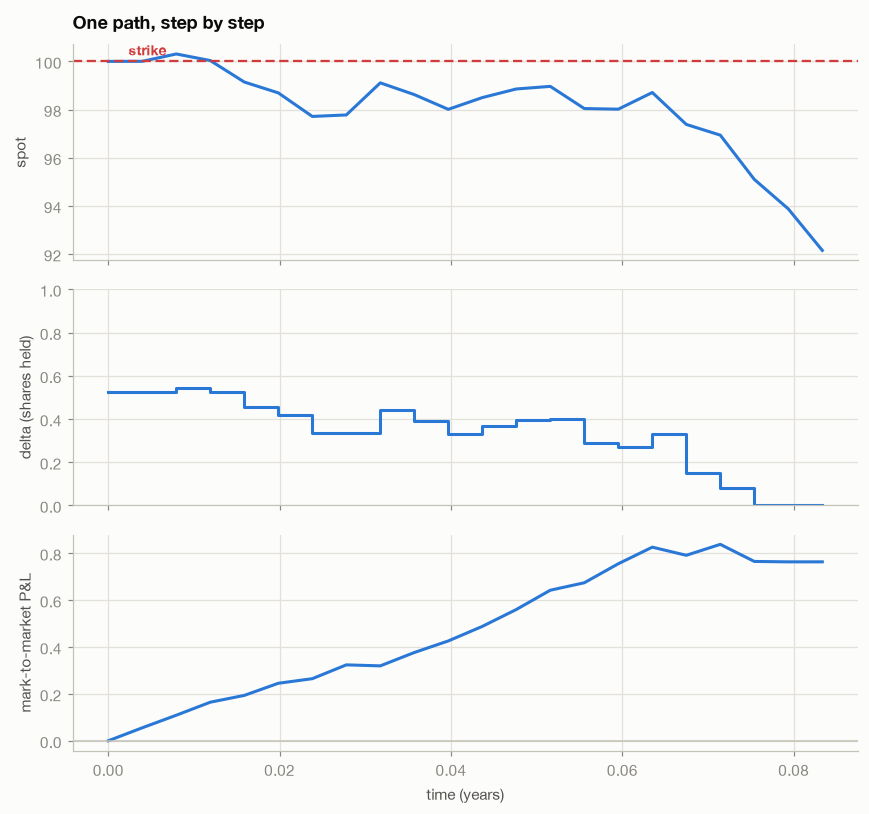

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(8, 7.5), sharex=True)

ax = axes[0]
ax.plot(tr["t"], tr["S"], color=T["series"], lw=2)
ax.axhline(CONTRACT["K"], color=T["critical"], lw=1.5, ls=(0, (4, 2)))
ax.annotate("strike", xy=(0.002, CONTRACT["K"]), xytext=(2, 4),
            textcoords="offset points", color=T["critical"], fontsize=9, fontweight="bold")
ax.set_ylabel("spot")
ax.set_title("One path, step by step", loc="left", fontsize=12,
             fontweight="bold", color=T["ink"], pad=10)

ax = axes[1]
ax.plot(tr["t"], tr["delta"], color=T["series"], lw=2, drawstyle="steps-post")
ax.set_ylabel("delta (shares held)")
ax.set_ylim(0, 1)

ax = axes[2]
# Mark-to-market P&L: cash + shares - what we owe on the option.
opt = np.array([
    mc.black_scholes_price(mc.OptionType.Call, s, CONTRACT["K"], CONTRACT["r"],
                           SIGMA_IMPLIED, max(CONTRACT["T"] - t, 1e-12))
    if CONTRACT["T"] - t > 1e-9 else max(s - CONTRACT["K"], 0.0)
    for s, t in zip(tr["S"], tr["t"])
])
mtm = tr["cash"] + tr["delta"] * tr["S"] - opt
ax.plot(tr["t"], mtm, color=T["series"], lw=2)
ax.axhline(0, color=T["axis"], lw=1)
ax.set_ylabel("mark-to-market P&L")
ax.set_xlabel("time (years)")

for a in axes:
    a.grid(True, lw=0.8)
    a.set_axisbelow(True)
    for side in ("top", "right"):
        a.spines[side].set_visible(False)
plt.tight_layout()
print(f"premium collected {tr['premium']:.4f} -> final P&L {tr['pnl']:+.4f}")

Three things are visible here that no aggregate statistic shows:

- **Delta is not a decision, it's a function of spot.** It walks up toward 1 as the path drifts
  above the strike and back down when it falls away. Every one of those moves is a trade.
- **The P&L does not accrue smoothly.** It grinds upward while the spot is calm and lurches on the
  big days — because the position is short gamma, and gamma only bites when the move is large.
- **The premium is collected on day one and is not the P&L.** Everything after `t=0` is the
  hedge either giving it back or letting you keep it.

## 2. Where the money actually accrues

The theory says the per-step P&L is

$$d\Pi \;\approx\; \tfrac12 S_t^2\,\Gamma_t\,\big(\sigma_{\text{impl}}^2\,dt - (dS/S)^2\big)$$

Two competing terms: a deterministic **theta-like credit** proportional to $\sigma_{\text{impl}}^2 dt$,
and a random **realized-variance debit** proportional to $(dS/S)^2$. You are paid for time and
charged for movement.

total credit +1.3011
total debit  -0.5146
net          +0.7865   (actual path P&L +0.7632)


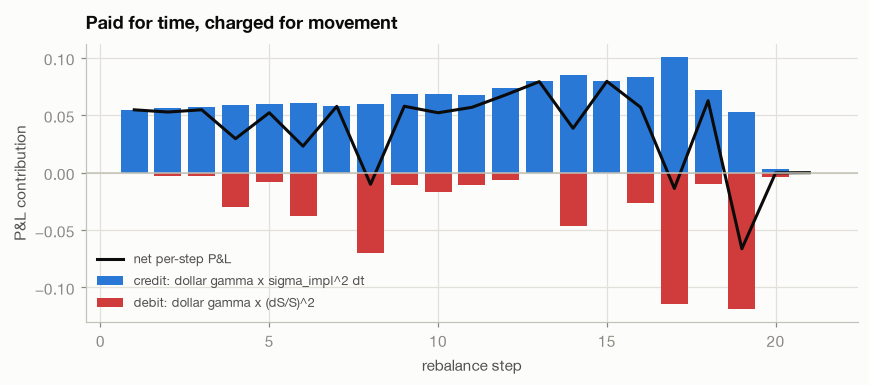

In [5]:
dt = CONTRACT["T"] / CONTRACT["n_steps"]
S_prev = tr["S"][:-1]
dollar_gamma = 0.5 * S_prev**2 * tr["gamma"]

credit = dollar_gamma * SIGMA_IMPLIED**2 * dt          # paid for time
debit = dollar_gamma * (tr["dS"] / S_prev) ** 2        # charged for movement
step_pnl = credit - debit

fig, ax = plt.subplots(figsize=(8, 3.6))
steps = np.arange(1, CONTRACT["n_steps"] + 1)
ax.bar(steps, credit, color=T["series"], label="credit: dollar gamma x sigma_impl^2 dt")
ax.bar(steps, -debit, color=T["critical"], label="debit: dollar gamma x (dS/S)^2")
ax.plot(steps, step_pnl, color=T["ink"], lw=2, label="net per-step P&L")
ax.axhline(0, color=T["axis"], lw=1)
ax.set_xlabel("rebalance step")
ax.set_ylabel("P&L contribution")
ax.set_title("Paid for time, charged for movement", loc="left", fontsize=12,
             fontweight="bold", color=T["ink"], pad=10)
leg = ax.legend(frameon=False, fontsize=8.5)
for t_ in leg.get_texts():
    t_.set_color(T["ink_secondary"])
ax.grid(True, lw=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()

print(f"total credit {credit.sum():+.4f}")
print(f"total debit  {-debit.sum():+.4f}")
print(f"net          {step_pnl.sum():+.4f}   (actual path P&L {tr['pnl']:+.4f})")

The credit bars are smooth and always positive; the debit bars are spiky. That asymmetry **is**
short gamma: a steady trickle in, occasional lumps out.

Note the two totals do not match exactly. The decomposition is a second-order Taylor expansion, so
it drops $O(dS^3)$ terms — and those are largest on exactly the days that matter most. Section 3
measures the size of that gap.

## 3. Verifying the gamma identity

Now the real test. Across many paths, does

$$\text{realized P\&L} \;\approx\; \tfrac12 \sum_t S_t^2\,\Gamma_t\,\big(\sigma_{\text{impl}}^2 - \sigma_{\text{real}}^2\big)\,dt$$

hold **path by path**, not just on average?

Note what the right-hand side contains: it uses the *expected* variance $\sigma_{\text{real}}^2 dt$,
not the realized $(dS/S)^2$. So it predicts the P&L a path *should* earn given where its gamma was —
and the difference is precisely the discrete-hedging noise.

In [6]:
def gamma_prediction(trace, *, sigma_implied, sigma_realized, dt):
    """The identity's right-hand side for one traced path."""
    S_prev = trace["S"][:-1]
    dollar_gamma = 0.5 * S_prev**2 * trace["gamma"]
    return float(np.sum(dollar_gamma * (sigma_implied**2 - sigma_realized**2) * dt))


def compare(n_paths, n_steps, seed=99):
    cfg = {**CONTRACT, "n_steps": n_steps}
    dt_ = cfg["T"] / n_steps
    rng = np.random.default_rng(seed)
    actual, predicted = [], []
    for _ in range(n_paths):
        pnl, trace = hedge_with_trace(
            sigma_implied=SIGMA_IMPLIED, sigma_realized=SIGMA_REALIZED, rng=rng, **cfg
        )
        actual.append(pnl)
        predicted.append(gamma_prediction(
            trace, sigma_implied=SIGMA_IMPLIED, sigma_realized=SIGMA_REALIZED, dt=dt_
        ))
    return np.array(actual), np.array(predicted)


actual, predicted = compare(n_paths=600, n_steps=21)
corr = np.corrcoef(actual, predicted)[0, 1]
print(f"correlation           {corr:.4f}")
print(f"mean actual           {actual.mean():+.4f}")
print(f"mean predicted        {predicted.mean():+.4f}")
print(f"mean absolute gap     {np.abs(actual - predicted).mean():.4f}")

correlation           0.6698
mean actual           +0.4814
mean predicted        +0.4585
mean absolute gap     0.2222


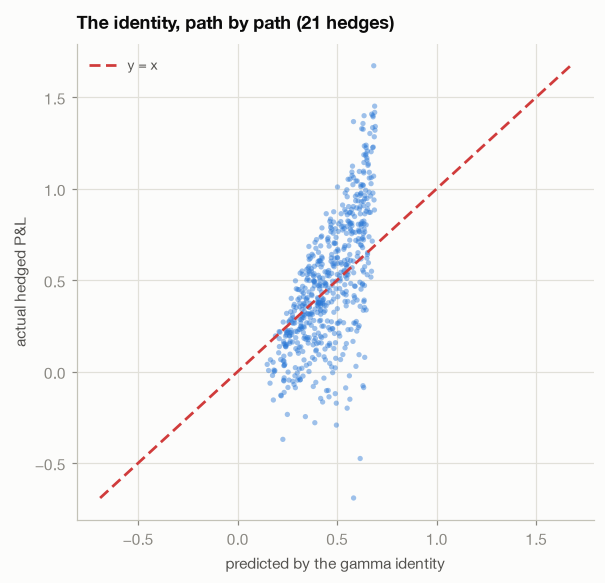

In [7]:
fig, ax = plt.subplots(figsize=(5.6, 5.4))
ax.scatter(predicted, actual, s=12, color=T["series"], alpha=0.45, edgecolor="none")
lims = [min(predicted.min(), actual.min()), max(predicted.max(), actual.max())]
ax.plot(lims, lims, color=T["critical"], lw=1.8, ls=(0, (4, 2)), label="y = x")
ax.set_xlabel("predicted by the gamma identity")
ax.set_ylabel("actual hedged P&L")
ax.set_title("The identity, path by path (21 hedges)", loc="left",
             fontsize=12, fontweight="bold", color=T["ink"], pad=10)
leg = ax.legend(frameon=False, fontsize=9)
for t_ in leg.get_texts():
    t_.set_color(T["ink_secondary"])
ax.grid(True, lw=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()

The cloud sits on `y = x` but is *wide*. That width is the discrete-hedging error — the identity
is a **continuous-time** statement, and with only 21 rebalances the realized variance of any one
path wanders a long way from its expectation.

So the sharp test is not "is the gap zero?" — it is "**does the gap vanish as the hedge refines?**"
If the identity is right, the scatter must tighten onto the diagonal as `n_steps` grows.

In [8]:
rows = []
for n_steps in (7, 21, 63, 189):
    a, p = compare(n_paths=600, n_steps=n_steps, seed=99)
    gap = a - p
    rows.append((n_steps, np.corrcoef(a, p)[0, 1], gap.std(), np.abs(gap).mean()))

print(f"{'n_steps':>8} {'corr':>8} {'std(gap)':>10} {'mean|gap|':>10} {'std x sqrt(n)':>14}")
for n_steps, c, sd, mad in rows:
    print(f"{n_steps:>8} {c:>8.4f} {sd:>10.4f} {mad:>10.4f} {sd * np.sqrt(n_steps):>14.4f}")

 n_steps     corr   std(gap)  mean|gap|  std x sqrt(n)
       7   0.6163     0.5149     0.3974         1.3622
      21   0.6698     0.2887     0.2222         1.3228
      63   0.7342     0.1744     0.1292         1.3840
     189   0.8395     0.1002     0.0758         1.3778


That is the result worth having. The correlation climbs toward 1 and the gap's standard deviation
falls — and the final column shows it falling like $1/\sqrt{n}$, since `std x sqrt(n)` is roughly
constant.

**The identity is exact in the continuous limit, and the entire discrepancy at finite `n` is
discretization noise, not model error.** That is the strongest available evidence that the P&L
engine computes what the theory says it should — and it is a different kind of evidence from
either the sign tests or the vega magnitude check.

## 4. Where the left tail comes from

One line explains the shape of every distribution in this project. Writing the per-step realized
variance as $(dS/S)^2 = \sigma_{\text{real}}^2\,dt\,Z^2$ with $Z \sim N(0,1)$:

$$d\Pi \;\approx\; \tfrac12 S^2\Gamma\,\sigma_{\text{real}}^2\,dt\;\Big(\tfrac{\sigma_{\text{impl}}^2}{\sigma_{\text{real}}^2} - Z^2\Big)$$

$Z^2$ is $\chi^2_1$ — strongly right-skewed, with a long right tail — and it enters with a **minus
sign**. The P&L therefore inherits a left skew directly from the chi-squared distribution of
squared returns.

fraction of steps that LOSE money: 21.2%
skew of the per-step contribution: -2.85


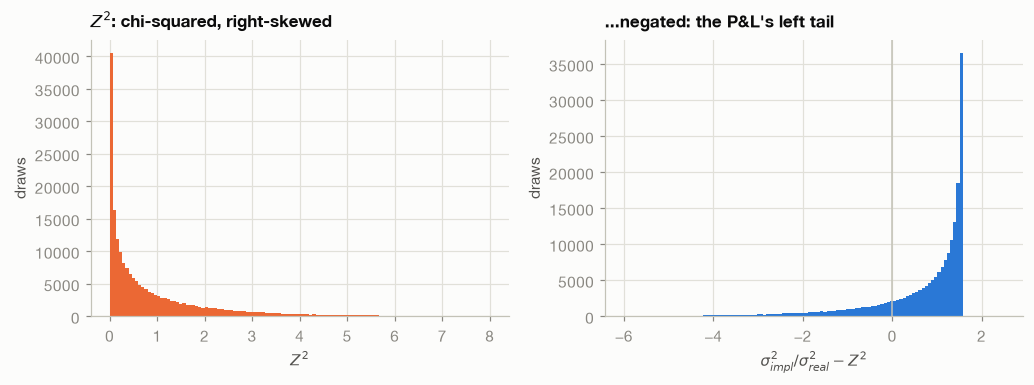

In [9]:
z = np.random.default_rng(0).standard_normal(200_000)
ratio = (SIGMA_IMPLIED / SIGMA_REALIZED) ** 2
contribution = ratio - z**2  # the bracket above, in units of the dollar-gamma scale

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))

axes[0].hist(z**2, bins=120, range=(0, 8), color=T["contrast"], lw=0)
axes[0].set_title("$Z^2$: chi-squared, right-skewed", loc="left",
                  fontsize=11, fontweight="bold", color=T["ink"], pad=8)
axes[0].set_xlabel("$Z^2$")

axes[1].hist(contribution, bins=120, range=(-6, 2.5), color=T["series"], lw=0)
axes[1].axvline(0, color=T["axis"], lw=1)
axes[1].set_title("...negated: the P&L's left tail", loc="left",
                  fontsize=11, fontweight="bold", color=T["ink"], pad=8)
axes[1].set_xlabel(r"$\sigma_{impl}^2/\sigma_{real}^2 - Z^2$")

for a in axes:
    a.set_ylabel("draws")
    a.grid(True, lw=0.8)
    a.set_axisbelow(True)
    for side in ("top", "right"):
        a.spines[side].set_visible(False)
plt.tight_layout()

print(f"fraction of steps that LOSE money: {(contribution < 0).mean():.1%}")
print(f"skew of the per-step contribution: {float(((contribution - contribution.mean())**3).mean() / contribution.std()**3):+.2f}")

Selling 20% vol into 16% realized, an individual step still loses money **more than a fifth of the
time** — a one-standard-deviation-and-a-bit move is enough. The premium is not a cushion against
any single day; it is a cushion against their average.

And the skew is inherited, not assumed. Everything downstream — the left-skewed P&L histogram, the
CVaR that stays negative while the mean is positive, the tail that fattens under Heston and fattens
further on real returns — follows from that minus sign in front of $Z^2$.

In [10]:
# The aggregate picture the README reports, for context.
summarize_pnl(vrp_pnl_paths(
    sigma_implied=SIGMA_IMPLIED, sigma_realized=SIGMA_REALIZED, n_paths=20_000, seed=11,
))

VrpResult(n=20000, mean=+0.4646, std=0.3752, sharpe=1.238, CVaR5%=-0.2537, win=90.8%)

---

**Where to go next**

- [`README.md`](../README.md) — the aggregate results: the VRP curve, the Heston stress, costs and
  hedge frequency, the skew ladder, and the premium measured from 36 years of VIX.
- `vrp/hedge.py` — the production core this notebook instruments.
- `vrp/bootstrap.py` — the same hedge driven by resampled real S&P returns instead of Gaussians.